In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('1.ushape.csv',header=None,names=['X','Y','Class'])

In [9]:
df.head()

,X,Y,Class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


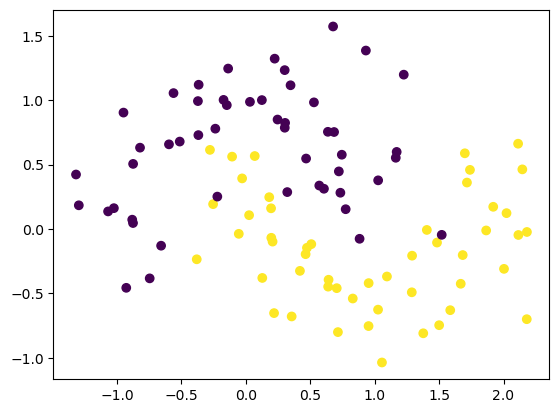

In [13]:
plt.scatter(df['X'],df['Y'],c=df['Class'])

In [43]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [45]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [47]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\cipl\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Set parameters to 0
model.get_weights()

[array([[ 0.3566357 , -0.15895212],
        [ 1.212633  , -0.22346675]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.8039707],
        [-1.0226903]], dtype=float32),
 array([0.], dtype=float32)]

In [51]:
initial_weights = model.get_weights()

In [53]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [55]:
model.set_weights(initial_weights)

In [61]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [63]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [65]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.5117 - loss: 0.9207 - val_accuracy: 0.5000 - val_loss: 0.8205
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5195 - loss: 0.9089 - val_accuracy: 0.5000 - val_loss: 0.8176
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5273 - loss: 0.8779 - val_accuracy: 0.5000 - val_loss: 0.8147
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4938 - loss: 0.9351 - val_accuracy: 0.5000 - val_loss: 0.8118
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5039 - loss: 0.9077 - val_accuracy: 0.5000 - val_loss: 0.8090
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4844 - loss: 0.9281 - val_accuracy: 0.5000 - val_loss: 0.8062
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4805 - loss: 0.9092 - val_accuracy: 0.5000 - val_loss: 0.8035
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4883 - loss: 0.9187 - val_accuracy: 0.5000 - val_loss

In [69]:
model.get_weights()

[array([[0.5307116, 0.5307116],
        [0.2522608, 0.2522608]], dtype=float32),
 array([0.30207452, 0.30207452], dtype=float32),
 array([[0.2902089],
        [0.2902089]], dtype=float32),
 array([0.25291777], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step


<Axes: >

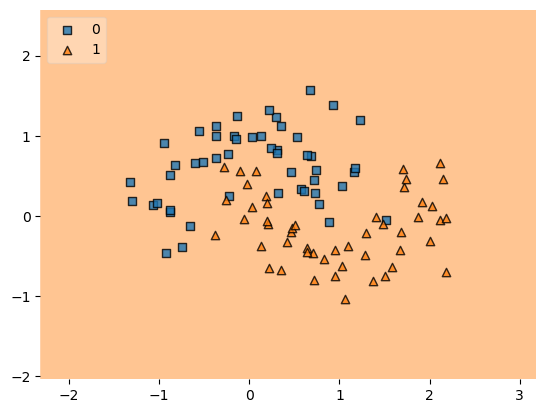

In [71]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)